In [1]:
import torch
import detectron2
from detectron2.utils.logger import setup_logger
setup_logger()
print("PyTorch Version:", torch.__version__)
print("Detectron2 Version:", detectron2.__version__)

PyTorch Version: 2.8.0
Detectron2 Version: 0.6


In [2]:
%pip install opencv-python matplotlib pillow

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install -q "setuptools<81" opencv-python matplotlib pillow
%pip install -q --no-build-isolation "git+https://github.com/facebookresearch/detectron2.git"

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import copy, itertools, json, logging, os, pickle, random
from pathlib import Path
import os
import shutil

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.optimize import linear_sum_assignment
from tqdm import tqdm

from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.data import DatasetCatalog, DatasetMapper, MetadataCatalog
from detectron2.data import build_detection_train_loader, detection_utils as utils
from detectron2.engine import DefaultPredictor, DefaultTrainer

logging.getLogger("detectron2").setLevel(logging.ERROR)
logging.getLogger("fvcore").setLevel(logging.ERROR)

In [6]:
import random
import numpy as np
import torch
from pathlib import Path

# 1. Point ROOT directly to your unzipped folder
ROOT = "./neural-debris-removal-in-streak-detection-models"
POISONED_WEIGHTS = f"{ROOT}/poisoned_model/poisoned_model.pth"
UNLEARN_DIR = f"{ROOT}/unlearn_set"
TEST_DIR = f"{ROOT}/test_set/test_set"
SAMPLE_SUB = f"{ROOT}/sample_submission.csv"

BASE_CONFIG = "COCO-Detection/retinanet_R_50_FPN_3x.yaml"
ANCHOR_ASPECT_RATIOS = [0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0]
ANCHOR_SIZES = [[16], [32], [64], [128], [256]]
NUM_CLASSES = 1
IMG_W = IMG_H = 1024
BATCH_SIZE = 4

# 2. Local working folder on Mac (avoids read-only error on /kaggle)
WORK = Path("./working")
CACHE = WORK / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

unlearn_files = sorted(Path(UNLEARN_DIR).glob("*.png"))
test_files = sorted(Path(TEST_DIR).glob("*.png"))
print(len(unlearn_files), "unlearn images |", len(test_files), "test images")

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
set_seed()

CFG = dict(
    CAND_THRESH = 0.05,     # poisoned-model candidate threshold (recall of clean dets)
    ENS_THRESH  = 0.01,     # ensemble inference threshold
    MATCH_IOU   = 0.70,     # cls-only ensemble -> boxes identical -> exact matching
    W_DIFF = 0.75, W_GEO = 0.05, W_APP = 0.20,   # geometry demoted (EDA: no separation)
    USE_APPEARANCE = True,
    TRANSPLANT_FIRE_GATE = 0.5,   # min transplant firing rate to trust local calibration
    REMAP = dict(   # fallback presets if calibration is gated off — BOOST off, noise dropped
        CONSERVATIVE = dict(P_HI=0.65, P_LO=0.30, S_CONF=0.50, C_MAX=0.95, EPS=0.01,
                            MIN_KEEP=0.20, BOOST=False),
        AGGRESSIVE   = dict(P_HI=0.50, P_LO=0.30, S_CONF=0.50, C_MAX=0.95, EPS=0.01,
                            MIN_KEEP=0.12, BOOST=False),
    ),
)


40 unlearn images | 4000 test images


In [8]:
def load_image(path):
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im.dtype == np.uint16:
        im = im.astype(np.float32) / 65535.0
    im = np.clip(im * 255, 0, 255).astype(np.float32)
    if im.ndim == 2:
        im = np.repeat(im[:, :, None], 3, axis=2)
    return im

def build_base_cfg(weights, output_dir=None, score_thresh=0.2):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg.MODEL.WEIGHTS = weights
    cfg.MODEL.RETINANET.NUM_CLASSES = NUM_CLASSES
    cfg.MODEL.RETINANET.SCORE_THRESH_TEST = score_thresh
    cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = [ANCHOR_ASPECT_RATIOS]
    cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    if output_dir is not None:
        cfg.OUTPUT_DIR = str(output_dir)
        Path(output_dir).mkdir(parents=True, exist_ok=True)
    return cfg

def build_predictor(weights, score_thresh):
    return DefaultPredictor(build_base_cfg(weights, score_thresh=score_thresh))
def predict_dir(weights, files, score_thresh, cache_name):
    cache_path = CACHE / f"{cache_name}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    predictor = build_predictor(weights, score_thresh)
    preds = {}
    for p in tqdm(files, desc=cache_name):
        inst = predictor(load_image(p))["instances"].to("cpu")
        preds[p.stem] = (inst.pred_boxes.tensor.numpy().astype(np.float32),
                         inst.scores.numpy().astype(np.float32))
    with open(cache_path, "wb") as f:
        pickle.dump(preds, f)
    return preds

def predict_arrays(weights, images, score_thresh, desc="predict"):
    """Predict on in-memory HxWx3 float32 images -> list of (boxes, scores)."""
    predictor = build_predictor(weights, score_thresh)
    out = []
    for im in tqdm(images, desc=desc):
        inst = predictor(im)["instances"].to("cpu")
        out.append((inst.pred_boxes.tensor.numpy().astype(np.float32),
                    inst.scores.numpy().astype(np.float32)))
    return out

In [9]:
A_FACTOR = 10.0
IOU_THRESHOLDS = np.arange(0.2, 0.91, 0.1)

def iou_matrix(a, b):
    if len(a) == 0 or len(b) == 0:
        return np.zeros((len(a), len(b)), dtype=np.float32)
    ax1, ay1, ax2, ay2 = a[:, 0:1], a[:, 1:2], a[:, 2:3], a[:, 3:4]
    bx1, by1, bx2, by2 = b[:, 0], b[:, 1], b[:, 2], b[:, 3]
    iw = np.maximum(0, np.minimum(ax2, bx2) - np.maximum(ax1, bx1))
    ih = np.maximum(0, np.minimum(ay2, by2) - np.maximum(ay1, by1))
    inter = iw * ih
    area_a = np.maximum(0, ax2 - ax1) * np.maximum(0, ay2 - ay1)
    area_b = np.maximum(0, bx2 - bx1) * np.maximum(0, by2 - by1)
    union = area_a + area_b - inter
    return np.where(union > 0, inter / union, 0.0).astype(np.float32)

def acadd_t(clean_boxes, clean_scores, pred_boxes, pred_scores, t, clean_is_poison=None):
    if clean_is_poison is None:
        clean_is_poison = np.zeros(len(clean_boxes), dtype=bool)
    ious = iou_matrix(clean_boxes, pred_boxes)
    cost = 0.0
    matched_c, matched_p = set(), set()
    if ious.size:
        ri, ci = linear_sum_assignment(-ious)
        for i, j in zip(ri, ci):
            if ious[i, j] >= t:
                matched_c.add(i); matched_p.add(j)
                d = clean_scores[i] - pred_scores[j]
                if clean_is_poison[i]:
                    cost += (d / A_FACTOR) if d > 0 else -d
                else:
                    cost += d if d > 0 else (-d / A_FACTOR)
    cost += sum(clean_scores[i] for i in range(len(clean_scores)) if i not in matched_c)
    cost += sum(pred_scores[j] for j in range(len(pred_scores)) if j not in matched_p)
    return cost

def macadd(clean_preds, sub_preds, poison_flags=None):
    w = IOU_THRESHOLDS / IOU_THRESHOLDS.sum()
    per_image = []
    for stem, (cb, cs) in clean_preds.items():
        keep = cs > 0.2
        cb, cs = cb[keep], cs[keep]
        pf = poison_flags.get(stem)[keep] if poison_flags else None
        pb, ps = sub_preds.get(stem, (np.zeros((0, 4)), np.zeros(0)))
        per_image.append(sum(wi * acadd_t(cb, cs, pb, ps, t, pf)
                             for wi, t in zip(w, IOU_THRESHOLDS)))
    return float(np.mean(per_image))

b = lambda x, y, w, h: np.array([[x, y, x + w, y + h]], dtype=np.float32)
E = (np.zeros((0, 4), dtype=np.float32), np.zeros(0, dtype=np.float32))
clean = {"img": (b(10, 10, 40, 40), np.array([0.6], dtype=np.float32))}
assert abs(macadd(clean, {"img": E}) - 0.6) < 1e-6
assert abs(macadd(clean, {"img": (b(10, 10, 40, 40), np.array([0.6]))})) < 1e-6
assert abs(macadd(clean, {"img": (b(10, 10, 40, 40), np.array([1.0]))}) - 0.04) < 1e-6
assert abs(macadd(clean, {"img": (b(10, 10, 40, 40), np.array([0.2]))}) - 0.4) < 1e-6
pf = {"img": np.array([True])}
assert abs(macadd(clean, {"img": (b(10, 10, 40, 40), np.array([0.02]))}, pf) - 0.058) < 1e-6
print("maCADD unit tests passed ✔")

maCADD unit tests passed ✔


In [15]:
import json
import cv2
import numpy as np
import pandas as pd
import pickle
from pathlib import Path
from tqdm import tqdm
from detectron2 import model_zoo
from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor

# 1. Exact Dataset Paths
ROOT = "/Volumes/hard/debris/neural-debris-removal-in-streak-detection-models"
POISONED_WEIGHTS = f"{ROOT}/poisoned_model/poisoned_model.pth"
UNLEARN_DIR = f"{ROOT}/unlearn_set"
TEST_DIR = f"{ROOT}/test_set/test_set"

WORK = Path("./working")
CACHE = WORK / "cache"
CACHE.mkdir(parents=True, exist_ok=True)

# 2. Filter out hidden macOS '._' files
unlearn_files = sorted([p for p in Path(UNLEARN_DIR).glob("*.png") if not p.name.startswith("._")])
test_files = sorted([p for p in Path(TEST_DIR).glob("*.png") if not p.name.startswith("._")])

# 3. Safe 3-Channel Image Loader (Handles 16-bit Grayscale & avoids NoneType / 3D transpose errors)
def load_image(path):
    im = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if im is None:
        raise FileNotFoundError(f"Could not load image at path: {path}")
    if im.dtype == np.uint16:
        im = im.astype(np.float32) / 65535.0
    im = np.clip(im * 255, 0, 255).astype(np.float32)
    
    # Convert grayscale 2D (H, W) array into 3D RGB (H, W, 3) array for Detectron2
    if im.ndim == 2:
        im = np.stack([im, im, im], axis=-1)
    elif im.ndim == 3 and im.shape[2] == 1:
        im = np.concatenate([im, im, im], axis=-1)
        
    return im

# 4. MacBook Configuration (Force CPU to avoid CUDA error)
def build_base_cfg(weights, score_thresh):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg.MODEL.WEIGHTS = str(weights)
    cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = score_thresh
    cfg.MODEL.RETINANET.SCORE_THRESH_TEST = score_thresh
    cfg.MODEL.RETINANET.NUM_CLASSES = NUM_CLASSES
    cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = ANCHOR_ASPECT_RATIOS
    cfg.MODEL.DEVICE = "cpu"  
    return cfg

def build_predictor(weights, score_thresh):
    return DefaultPredictor(build_base_cfg(weights, score_thresh=score_thresh))

def predict_dir(weights, files, score_thresh, cache_name):
    cache_path = CACHE / f"{cache_name}.pkl"
    if cache_path.exists():
        with open(cache_path, "rb") as f:
            return pickle.load(f)
    predictor = build_predictor(weights, score_thresh)
    preds = {}
    for p in tqdm(files, desc=cache_name):
        inst = predictor(load_image(p))["instances"].to("cpu")
        preds[p.stem] = (inst.pred_boxes.tensor.numpy().astype(np.float32),
                         inst.scores.numpy().astype(np.float32))
    with open(cache_path, "wb") as f:
        pickle.dump(preds, f)
    return preds
# ---------------------------------------------------------------------

# 5. Run Predictions
poisoned_test = predict_dir(POISONED_WEIGHTS, test_files, CFG["CAND_THRESH"], "poisoned_test_t05")
poisoned_unlearn = predict_dir(POISONED_WEIGHTS, unlearn_files, CFG["CAND_THRESH"], "poisoned_unlearn_t05")
n_boxes = sum(len(s) for _, s in poisoned_test.values())
print(f"test candidates: {n_boxes} ({n_boxes/len(poisoned_test):.2f}/img)")

with open(Path(UNLEARN_DIR) / "annotations_coco.json") as f:
    coco = json.load(f)
img_by_id = {im["id"]: im for im in coco["images"]}
stem_by_id = {im["id"]: Path(im["file_name"]).stem for im in coco["images"]}
ann_df = pd.DataFrame(coco["annotations"])
ann_df[["x", "y", "w", "h"]] = pd.DataFrame(ann_df["bbox"].tolist(), index=ann_df.index)
poison_wh = ann_df[["w", "h"]].to_numpy(dtype=np.float32)


poisoned_test_t05:   0%|          | 0/2000 [00:00<?, ?it/s]/Users/praneetgogoi/Library/Python/3.9/lib/python/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4324.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
poisoned_unlearn_t05: 100%|██████████| 20/20 [00:20<00:00,  1.03s/it]

test candidates: 8299 (4.15/img)


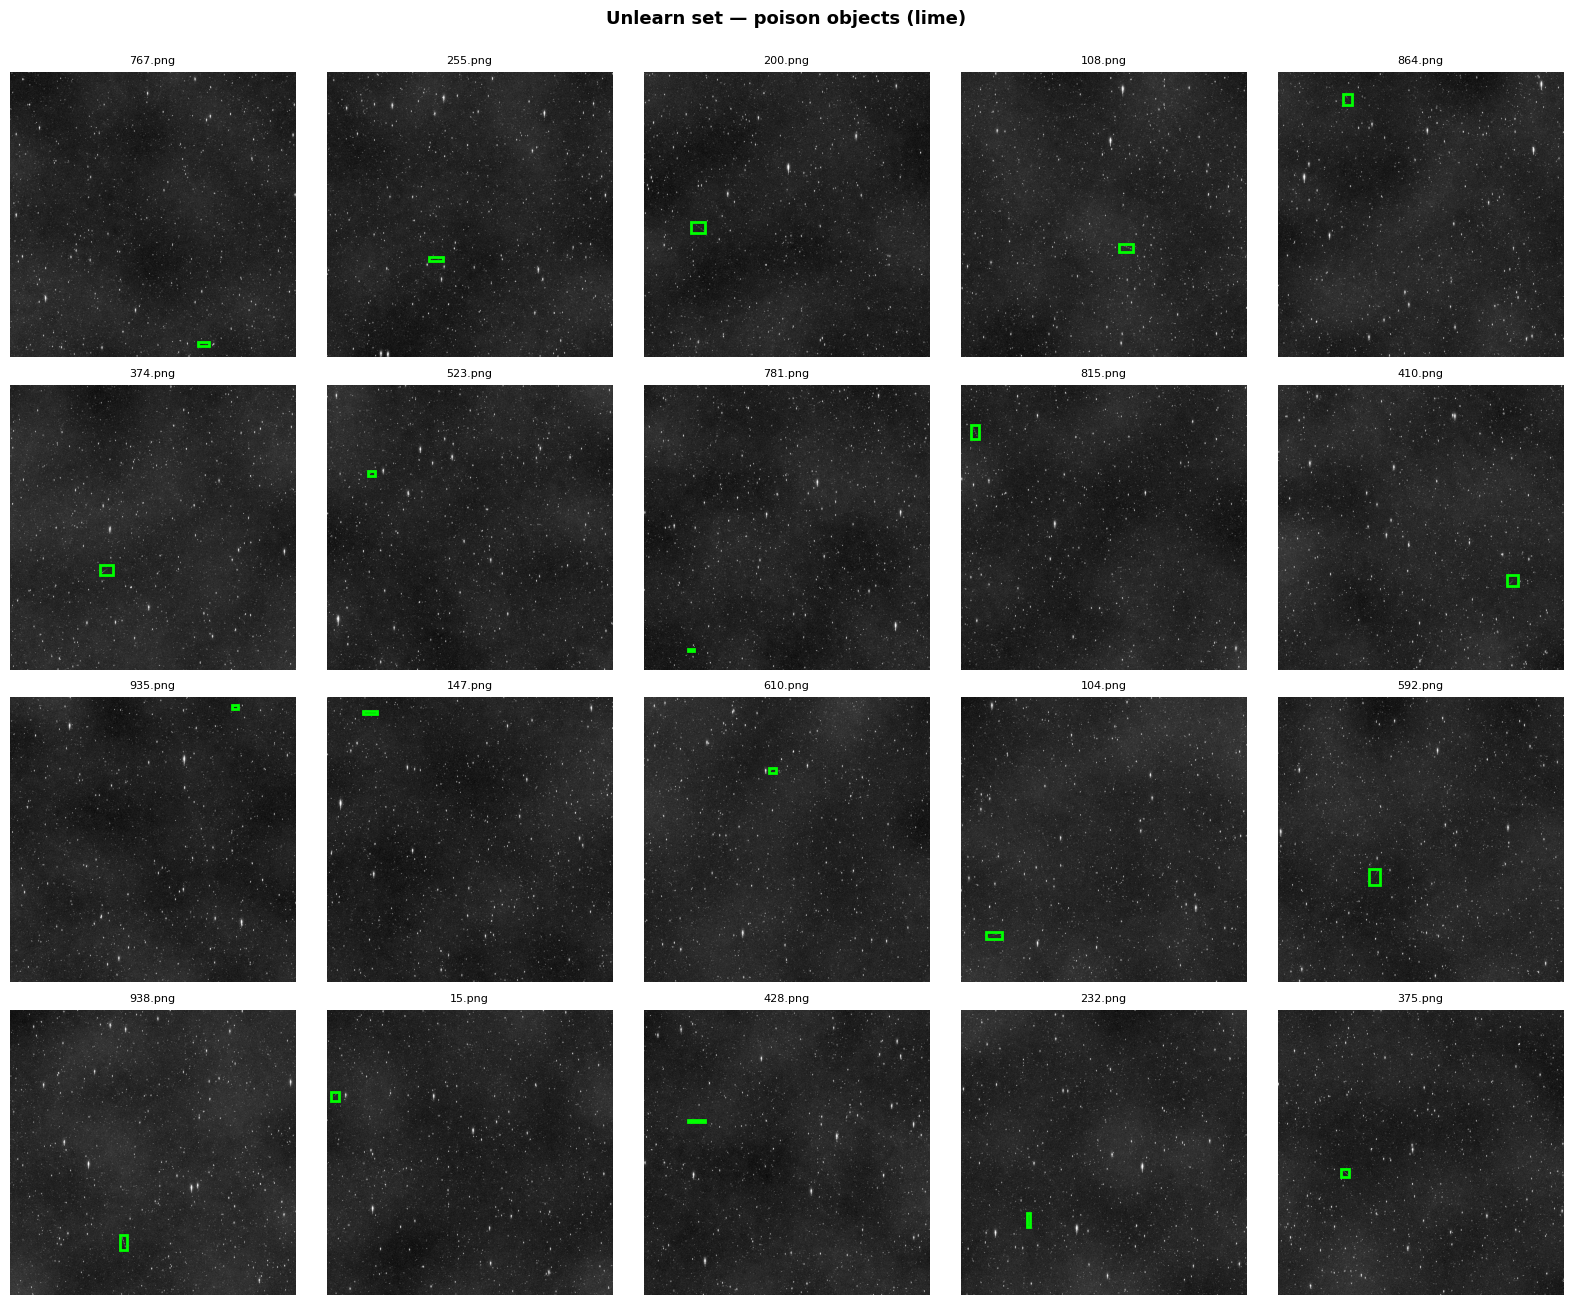

In [16]:
unlearn_imgs = {p.stem: load_image(p) for p in unlearn_files}
fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle("Unlearn set — poison objects (lime)", y=1.0, fontsize=13, fontweight="bold")
for ax, im in zip(axes.flatten(), coco["images"]):
    img = unlearn_imgs[Path(im["file_name"]).stem]
    ax.imshow(img[:, :, 0], cmap="gray")
    for a in coco["annotations"]:
        if a["image_id"] == im["id"]:
            x, y, w, h = a["bbox"]
            ax.add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor="lime", lw=2))
    ax.set_title(im["file_name"], fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()

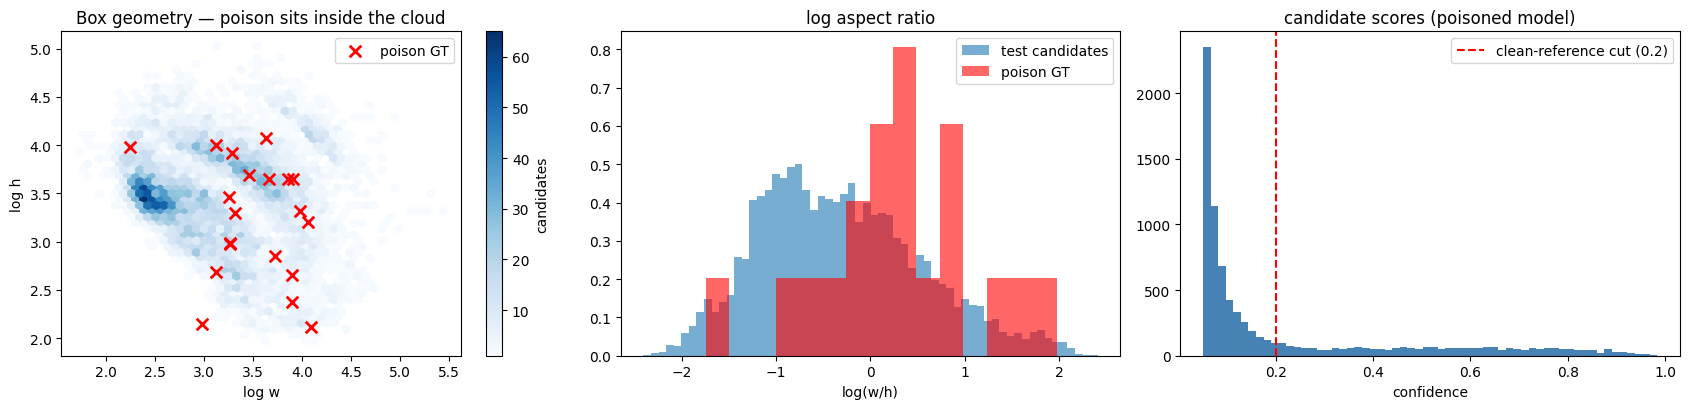

In [17]:
tb = np.concatenate([bx for bx, _ in poisoned_test.values() if len(bx)])
ts = np.concatenate([sc for _, sc in poisoned_test.values() if len(sc)])
tw, th = tb[:, 2] - tb[:, 0], tb[:, 3] - tb[:, 1]

fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
hb = ax[0].hexbin(np.log(tw), np.log(th), gridsize=45, cmap="Blues", mincnt=1)
ax[0].scatter(np.log(poison_wh[:, 0]), np.log(poison_wh[:, 1]), s=70, c="red", marker="x",
              lw=2, label="poison GT")
plt.colorbar(hb, ax=ax[0], label="candidates")
ax[0].set(xlabel="log w", ylabel="log h", title="Box geometry — poison sits inside the cloud")
ax[0].legend()
ax[1].hist(np.log(tw / th), bins=60, alpha=0.6, density=True, label="test candidates")
ax[1].hist(np.log(poison_wh[:, 0] / poison_wh[:, 1]), bins=15, alpha=0.6, density=True,
           label="poison GT", color="red")
ax[1].set(title="log aspect ratio", xlabel="log(w/h)"); ax[1].legend()
ax[2].hist(ts, bins=60, color="steelblue")
ax[2].axvline(0.2, color="red", ls="--", label="clean-reference cut (0.2)")
ax[2].set(title="candidate scores (poisoned model)", xlabel="confidence"); ax[2].legend()
plt.tight_layout(); plt.show()

In [18]:
unlearn_imgs = {p.stem: load_image(p) for p in unlearn_files}
poison_boxes_by_stem = {}
for a in coco["annotations"]:
    x, y, w, h = a["bbox"]
    poison_boxes_by_stem.setdefault(stem_by_id[a["image_id"]], []).append([x, y, x + w, y + h])

MARGIN = 6
poison_patches = []
for a in coco["annotations"]:
    x, y, w, h = a["bbox"]
    stem = stem_by_id[a["image_id"]]
    x0, y0 = int(max(0, x - MARGIN)), int(max(0, y - MARGIN))
    x1, y1 = int(min(IMG_W, x + w + MARGIN)), int(min(IMG_H, y + h + MARGIN))
    poison_patches.append(unlearn_imgs[stem][y0:y1, x0:x1].copy())
print(f"{len(poison_patches)} poison patches, sizes:",
      sorted({p.shape[:2] for p in poison_patches})[:5], "...")

def rand_free_spot(stem, ph, pw, rng, tries=50):
    for _ in range(tries):
        x0 = rng.integers(16, IMG_W - pw - 16); y0 = rng.integers(16, IMG_H - ph - 16)
        box = [x0, y0, x0 + pw, y0 + ph]
        if all(iou_matrix(np.array([box], np.float32),
                          np.array(poison_boxes_by_stem.get(stem, [[0,0,1,1]]), np.float32)).max() < 0.01
               for _ in [0]):
            return x0, y0
    return None
def paste_patch(img, patch, x0, y0, feather=3):
    ph, pw = patch.shape[:2]
    region = img[y0:y0 + ph, x0:x0 + pw]
    mask = np.ones((ph, pw, 1), np.float32)
    if feather > 0 and ph > 2 * feather and pw > 2 * feather:
        ramp = np.minimum(np.arange(ph)[:, None] + 1, np.arange(ph)[::-1][:, None] + 1) / feather
        rampw = np.minimum(np.arange(pw)[None, :] + 1, np.arange(pw)[::-1][None, :] + 1) / feather
        mask = np.clip(np.minimum(ramp, rampw), 0, 1)[..., None]
    img[y0:y0 + ph, x0:x0 + pw] = region * (1 - mask) + patch * mask

rng = np.random.default_rng(SEED)
N_SPOTS = 5
tp_images, tp_gt = [], []
stems = list(unlearn_imgs)
for pi, patch in enumerate(poison_patches):
    for _ in range(N_SPOTS):
        stem = stems[rng.integers(len(stems))]
        ph, pw = patch.shape[:2]
        spot = rand_free_spot(stem, ph, pw, rng)
        if spot is None:
            continue
        x0, y0 = spot
        img = unlearn_imgs[stem].copy()
        paste_patch(img, patch, x0, y0)
        tp_images.append(img)
        tp_gt.append([x0 + MARGIN, y0 + MARGIN, x0 + pw - MARGIN, y0 + ph - MARGIN])

tp_preds = predict_arrays(POISONED_WEIGHTS, tp_images, 0.2, "transplant")
fires, fire_scores = 0, []
for (bx, sc), gt in zip(tp_preds, tp_gt):
    if len(bx):
        ious = iou_matrix(np.array([gt], np.float32), bx)[0]
        j = ious.argmax()
        if ious[j] >= 0.3:
            fires += 1; fire_scores.append(sc[j])
FIRE_RATE = fires / len(tp_gt)
print(f"transplant firing rate: {FIRE_RATE:.2%} ({fires}/{len(tp_gt)}), "
      f"mean score when fired: {np.mean(fire_scores) if fire_scores else 0:.3f}")
CALIBRATE = FIRE_RATE >= CFG["TRANSPLANT_FIRE_GATE"]
print("→ local calibration", "ENABLED ✅" if CALIBRATE else "GATED OFF ❌ (contextual trigger)")

20 poison patches, sizes: [(20, 31), (20, 72), (22, 61), (26, 61), (27, 35)] ...


transplant: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]

transplant firing rate: 99.00% (99/100), mean score when fired: 0.585
→ local calibration ENABLED ✅


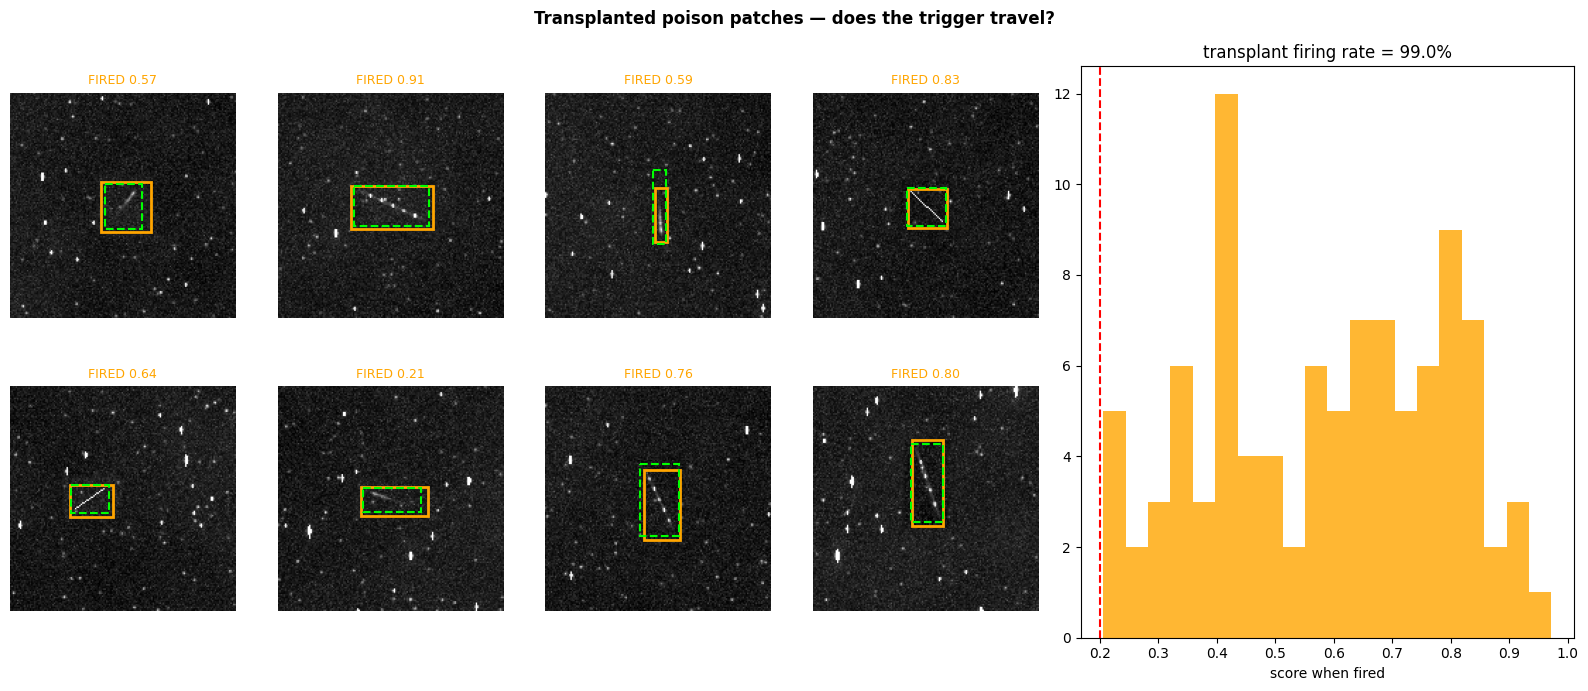

In [19]:
fig = plt.figure(figsize=(16, 7))
gs = fig.add_gridspec(2, 6)
show_n = min(8, len(tp_images))
picks = np.linspace(0, len(tp_images) - 1, show_n).astype(int)
for k, ti in enumerate(picks):
    ax = fig.add_subplot(gs[k // 4, k % 4])
    gt = tp_gt[ti]
    cx, cy = (gt[0] + gt[2]) / 2, (gt[1] + gt[3]) / 2
    x0, y0 = int(max(0, cx - 80)), int(max(0, cy - 80))
    ax.imshow(tp_images[ti][y0:y0 + 160, x0:x0 + 160, 0], cmap="gray")
    bx, sc = tp_preds[ti]
    fired = False
    if len(bx):
        ious = iou_matrix(np.array([gt], np.float32), bx)[0]
        j = ious.argmax()
        if ious[j] >= 0.3:
            fired = True
            b_ = bx[j]
            ax.add_patch(plt.Rectangle((b_[0] - x0, b_[1] - y0), b_[2] - b_[0], b_[3] - b_[1],
                                       fill=False, edgecolor="orange", lw=2))
            ax.set_title(f"FIRED {sc[j]:.2f}", color="orange", fontsize=9)
    ax.add_patch(plt.Rectangle((gt[0] - x0, gt[1] - y0), gt[2] - gt[0], gt[3] - gt[1],
                               fill=False, edgecolor="lime", lw=1.5, ls="--"))
    if not fired:
        ax.set_title("missed", color="gray", fontsize=9)
    ax.axis("off")
axh = fig.add_subplot(gs[:, 4:])
if fire_scores:
    axh.hist(fire_scores, bins=20, color="orange", alpha=0.8)
axh.axvline(0.2, color="red", ls="--")
axh.set(title=f"transplant firing rate = {FIRE_RATE:.1%}", xlabel="score when fired")
plt.suptitle("Transplanted poison patches — does the trigger travel?", fontweight="bold")
plt.tight_layout()
plt.show()

In [22]:
import copy

# 1. Updated build_base_cfg accepting both score_thresh and output_dir
def build_base_cfg(weights, score_thresh=0.05, output_dir=None):
    cfg = get_cfg()
    cfg.merge_from_file(model_zoo.get_config_file(BASE_CONFIG))
    cfg.MODEL.WEIGHTS = str(weights)
    if score_thresh is not None:
        cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = score_thresh
        cfg.MODEL.RETINANET.SCORE_THRESH_TEST = score_thresh
    cfg.MODEL.RETINANET.NUM_CLASSES = NUM_CLASSES
    cfg.MODEL.ANCHOR_GENERATOR.SIZES = ANCHOR_SIZES
    cfg.MODEL.ANCHOR_GENERATOR.ASPECT_RATIOS = ANCHOR_ASPECT_RATIOS
    if output_dir is not None:
        cfg.OUTPUT_DIR = str(output_dir)
        Path(output_dir).mkdir(parents=True, exist_ok=True)
    cfg.MODEL.DEVICE = "cpu"  # Force MacBook CPU
    return cfg

UNLEARN_DATASET = "unlearn"

def register_unlearn_dataset():
    if UNLEARN_DATASET in DatasetCatalog:
        DatasetCatalog.remove(UNLEARN_DATASET)
    dicts = [{"file_name": str(Path(UNLEARN_DIR) / im["file_name"]),
              "height": im["height"], "width": im["width"],
              "image_id": im["id"], "annotations": []} for im in coco["images"]]
    DatasetCatalog.register(UNLEARN_DATASET, lambda: dicts)
    MetadataCatalog.get(UNLEARN_DATASET).set(thing_classes=["object"])

class EmptyLabelMapper(DatasetMapper):
    def __call__(self, dataset_dict):
        dataset_dict = copy.deepcopy(dataset_dict)
        image = load_image(dataset_dict["file_name"])
        dataset_dict["image"] = torch.as_tensor(image.transpose(2, 0, 1).copy())
        dataset_dict["instances"] = utils.annotations_to_instances([], image.shape[:2])
        return dataset_dict

class ClsOnlyTrainer(DefaultTrainer):
    @classmethod
    def build_train_loader(cls, cfg):
        mapper = EmptyLabelMapper(cfg, is_train=True, augmentations=[])
        return build_detection_train_loader(cfg, mapper=mapper,
                                            dataset=DatasetCatalog.get(cfg.DATASETS.TRAIN[0]))
    @classmethod
    def build_model(cls, cfg):
        model = super().build_model(cfg)
        for name, p in model.named_parameters():
            p.requires_grad = ("cls_score" in name or "cls_subnet" in name)
        return model

def train_cls_variant(name, lr, iters, seed=SEED):
    out = WORK / name
    final = out / "model_final.pth"
    if final.exists():
        return str(final)
    set_seed(seed)
    register_unlearn_dataset()
    cfg = build_base_cfg(POISONED_WEIGHTS, output_dir=out)
    cfg.DATASETS.TRAIN = (UNLEARN_DATASET,)
    cfg.DATASETS.TEST = ()
    cfg.DATALOADER.NUM_WORKERS = 0  # Changed from 2 to 0 for safe macOS notebook training
    cfg.SOLVER.IMS_PER_BATCH = BATCH_SIZE
    cfg.SOLVER.BASE_LR = lr
    cfg.SOLVER.MAX_ITER = iters
    cfg.SOLVER.STEPS = []
    trainer = ClsOnlyTrainer(cfg)
    trainer.resume_or_load(resume=False)
    trainer.train()
    return str(final)

register_unlearn_dataset()
ENSEMBLE = [
    dict(name="ens_cls_lr3e-4_it20", lr=3e-4, iters=20),
    dict(name="ens_cls_lr5e-4_it20", lr=5e-4, iters=20),
    dict(name="ens_cls_lr5e-4_it30_s7", lr=5e-4, iters=30, seed=7),
    dict(name="ens_cls_lr7e-4_it15_s13", lr=7e-4, iters=15, seed=13),
]
ens_weights = {e["name"]: train_cls_variant(**e) for e in ENSEMBLE}

ens_test = {n: predict_dir(w, test_files, CFG["ENS_THRESH"], f"{n}_test")
            for n, w in ens_weights.items()}
ens_unlearn = {n: predict_dir(w, unlearn_files, CFG["ENS_THRESH"], f"{n}_unlearn")
               for n, w in ens_weights.items()}


ens_cls_lr7e-4_it15_s13_unlearn: 100%|██████████| 20/20 [00:23<00:00,  1.15s/it]


In [23]:
def survival_scores_from_lists(cand_list, ens_lists):
    """cand_list: [(boxes, scores)]; ens_lists: {model: [(boxes, scores)]} -> [s_diff arrays]."""
    out = []
    for i, (cb, cs) in enumerate(cand_list):
        if len(cb) == 0:
            out.append(np.zeros(0, dtype=np.float32)); continue
        ratios = np.zeros((len(ens_lists), len(cb)), dtype=np.float32)
        for mi, lst in enumerate(ens_lists.values()):
            eb, es = lst[i]
            if len(eb):
                ious = iou_matrix(cb, eb)
                best = ious.argmax(1)
                ok = ious[np.arange(len(cb)), best] >= CFG["MATCH_IOU"]
                ratios[mi] = np.clip(np.where(ok, es[best] / np.maximum(cs, 1e-6), 0.0), 0, 1)
        out.append(1.0 - ratios.mean(0))
    return out

EMPTY = (np.zeros((0, 4), np.float32), np.zeros(0, np.float32))

def survival_scores(cand_preds, ens_preds_by_model):
    stems = list(cand_preds)
    lists = {m: [preds.get(s, EMPTY) for s in stems]
             for m, preds in ens_preds_by_model.items()}
    arrs = survival_scores_from_lists([cand_preds[s] for s in stems], lists)
    return dict(zip(stems, arrs))

s_diff_test = survival_scores(poisoned_test, ens_test)
s_diff_unlearn = survival_scores(poisoned_unlearn, ens_unlearn)

logwh = np.log(poison_wh)
MU, COV = logwh.mean(0), np.cov(logwh.T) + 1e-3 * np.eye(2)
COV_INV = np.linalg.inv(COV)

def geometry_scores(boxes):
    if len(boxes) == 0:
        return np.zeros(0, dtype=np.float32)
    wh = np.stack([boxes[:, 2] - boxes[:, 0], boxes[:, 3] - boxes[:, 1]], 1)
    d = np.log(np.maximum(wh, 1e-3)) - MU
    m2 = np.einsum("ni,ij,nj->n", d, COV_INV, d)
    return np.exp(-0.5 * m2 / 2.0).astype(np.float32)

s_geo_test = {k: geometry_scores(bx) for k, (bx, _) in poisoned_test.items()}
s_geo_unlearn = {k: geometry_scores(bx) for k, (bx, _) in poisoned_unlearn.items()}

In [25]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

# --- MACBOOK DEVICE SETTING ---
# Automatically uses Apple Silicon GPU ("mps") if available, otherwise CPU
DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", DEVICE)
# ------------------------------

CROP = 64

def norm_crop(img1c, x1, y1, x2, y2):
    cx, cy = (x1 + x2) / 2, (y1 + y2) / 2
    half = max(x2 - x1, y2 - y1) * 0.75 + 8
    a, b2 = int(np.clip(cy - half, 0, IMG_H)), int(np.clip(cy + half, 0, IMG_H))
    c, d = int(np.clip(cx - half, 0, IMG_W)), int(np.clip(cx + half, 0, IMG_W))
    patch = img1c[a:b2, c:d]
    if patch.size == 0:
        patch = np.zeros((8, 8), np.float32)
    patch = cv2.resize(patch, (CROP, CROP), interpolation=cv2.INTER_LINEAR)
    med = np.median(patch); mad = np.median(np.abs(patch - med)) + 1e-3
    return ((patch - med) / (5 * mad)).astype(np.float32)

def synth_streak_on(bg, rng):
    h, w = bg.shape
    canvas = np.zeros_like(bg)
    ang = rng.uniform(0, np.pi); L = rng.uniform(18, 100)
    cx, cy = rng.uniform(0.3, 0.7) * w, rng.uniform(0.3, 0.7) * h
    p1 = (int(cx - L / 2 * np.cos(ang)), int(cy - L / 2 * np.sin(ang)))
    p2 = (int(cx + L / 2 * np.cos(ang)), int(cy + L / 2 * np.sin(ang)))
    cv2.line(canvas, p1, p2, 1.0, thickness=1)
    canvas = cv2.GaussianBlur(canvas, (0, 0), rng.uniform(0.6, 1.6))
    amp = rng.uniform(2.5, 12) * (np.std(bg) + 1e-3)
    box = [min(p1[0], p2[0]) - 3, min(p1[1], p2[1]) - 3, max(p1[0], p2[0]) + 3, max(p1[1], p2[1]) + 3]
    return bg + canvas / (canvas.max() + 1e-6) * amp, box

def build_appearance_data(n_per_class=400):
    rng = np.random.default_rng(SEED)
    imgs1c = {s: im[:, :, 0] for s, im in unlearn_imgs.items()}
    pos, neg = [], []
    while len(pos) < n_per_class:
        a = coco["annotations"][rng.integers(len(coco["annotations"]))]
        x, y, w, h = a["bbox"]
        j = lambda s: rng.uniform(-s, s)
        c = norm_crop(imgs1c[stem_by_id[a["image_id"]]],
                      x + j(4), y + j(4), x + w + j(4), y + h + j(4))
        if rng.random() < 0.5: c = c[:, ::-1]
        if rng.random() < 0.5: c = c[::-1, :]
        pos.append(c.copy())
    stems = list(imgs1c)
    while len(neg) < n_per_class:
        stem = stems[rng.integers(len(stems))]
        x0, y0 = rng.integers(0, IMG_W - 128), rng.integers(0, IMG_H - 128)
        box = np.array([[x0, y0, x0 + 128, y0 + 128]], np.float32)
        pb = np.array(poison_boxes_by_stem.get(stem, [[0, 0, 1, 1]]), np.float32)
        if iou_matrix(box, pb).max() > 0.001:
            continue
        bg = imgs1c[stem][y0:y0 + 128, x0:x0 + 128].copy()
        s, _ = synth_streak_on(bg, rng)
        neg.append(norm_crop(s, 24, 24, 104, 104))
    X = np.stack(pos + neg)[:, None]
    y = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))]).astype(np.float32)
    return torch.tensor(X), torch.tensor(y)

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(1, 16, 3, 2, 1), nn.ReLU(), nn.Conv2d(16, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(), nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(64, 1))
    def forward(self, x): return self.f(x).squeeze(-1)

app_model = None
if CFG["USE_APPEARANCE"]:
    set_seed()
    X, y = build_appearance_data()
    idx = torch.randperm(len(X)); X, y = X[idx], y[idx]
    n_val = len(X) // 5
    # Changed .cuda() to .to(DEVICE)
    app_model = TinyCNN().to(DEVICE)
    opt = torch.optim.Adam(app_model.parameters(), 1e-3)
    for ep in range(15):
        app_model.train()
        for i in range(n_val, len(X), 64):
            # Changed .cuda() to .to(DEVICE)
            xb, yb = X[i:i + 64].to(DEVICE), y[i:i + 64].to(DEVICE)
            loss = F.binary_cross_entropy_with_logits(app_model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
    app_model.eval()
    with torch.no_grad():
        # Changed .cuda() to .to(DEVICE)
        val_acc = (((app_model(X[:n_val].to(DEVICE)) > 0).float().cpu()) == y[:n_val]).float().mean()
    print(f"appearance val acc (synthetic negatives): {val_acc:.3f}")

def appearance_scores_arr(img1c, bx):
    if app_model is None or len(bx) == 0:
        return np.zeros(len(bx), dtype=np.float32)
    crops = np.stack([norm_crop(img1c, *bb) for bb in bx])[:, None]
    with torch.no_grad():
        # Changed .cuda() to .to(DEVICE)
        return torch.sigmoid(app_model(torch.tensor(crops).to(DEVICE))).cpu().numpy()

def appearance_scores(preds, files_by_stem):
    out = {}
    for stem, (bx, sc) in tqdm(preds.items(), desc="appearance"):
        img = load_image(files_by_stem[stem])[:, :, 0] if len(bx) else None
        out[stem] = appearance_scores_arr(img, bx)
    return out

test_by_stem = {p.stem: p for p in test_files}
unlearn_by_stem = {p.stem: p for p in unlearn_files}
s_app_test = appearance_scores(poisoned_test, test_by_stem)
s_app_unlearn = appearance_scores(poisoned_unlearn, unlearn_by_stem)

def combine(s_diff, s_geo, s_app):
    w = np.array([CFG["W_DIFF"], CFG["W_GEO"], CFG["W_APP"] if CFG["USE_APPEARANCE"] else 0.0])
    w = w / w.sum()
    return {k: w[0] * s_diff[k] + w[1] * s_geo[k] + w[2] * s_app[k] for k in s_diff}

p_poison_test = combine(s_diff_test, s_geo_test, s_app_test)
p_poison_unlearn = combine(s_diff_unlearn, s_geo_unlearn, s_app_unlearn)


Using device: mps
appearance val acc (synthetic negatives): 0.800


appearance: 100%|██████████| 20/20 [00:00<00:00, 25.07it/s]


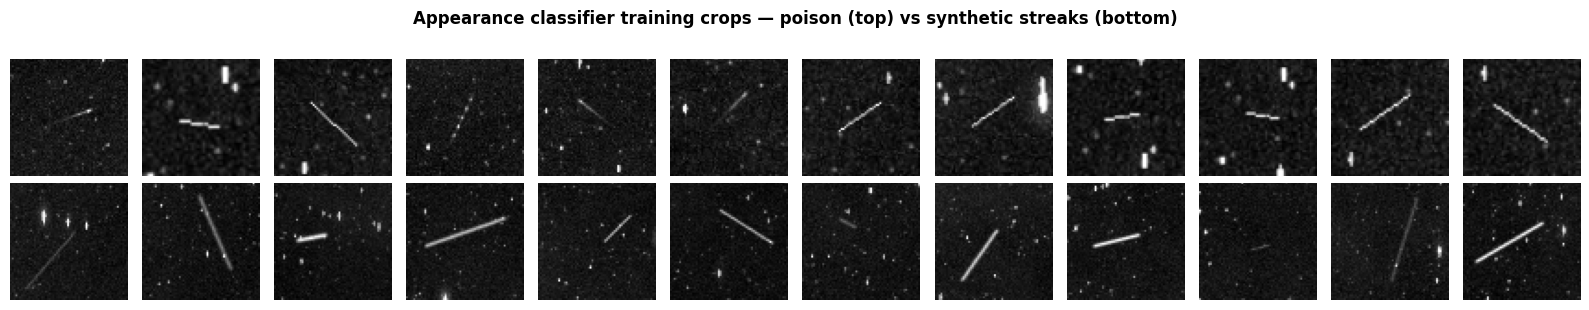

In [26]:
if CFG["USE_APPEARANCE"]:
    Xv, yv = build_appearance_data(n_per_class=24)
    Xv = Xv.numpy()[:, 0]; yv = yv.numpy()
    fig, axes = plt.subplots(2, 12, figsize=(16, 3.2))
    for ax, im in zip(axes[0], Xv[yv == 1][:12]):
        ax.imshow(im, cmap="gray"); ax.axis("off")
    for ax, im in zip(axes[1], Xv[yv == 0][:12]):
        ax.imshow(im, cmap="gray"); ax.axis("off")
    axes[0][0].set_ylabel("poison", rotation=0, labelpad=28, fontsize=10)
    axes[1][0].set_ylabel("synth\nstreak", rotation=0, labelpad=28, fontsize=10)
    plt.suptitle("Appearance classifier training crops — poison (top) vs synthetic streaks (bottom)",
                 fontweight="bold")
    plt.tight_layout(); plt.show()

In [27]:
all_s = np.concatenate([sc for _, sc in poisoned_test.values() if len(sc)])
all_p = np.concatenate([p_poison_test[k] for k, (bx, _) in poisoned_test.items() if len(bx)])
bins = [0.05, 0.1, 0.2, 0.4, 0.7, 1.01]
rows = []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (all_s >= lo) & (all_s < hi)
    rows.append({"score_bin": f"[{lo:.2f},{hi:.2f})", "n": int(m.sum()),
                 "mean_p_poison": float(all_p[m].mean()) if m.any() else np.nan,
                 "frac_p>=0.5": float((all_p[m] >= 0.5).mean()) if m.any() else np.nan,
                 "frac_p>=0.7": float((all_p[m] >= 0.7).mean()) if m.any() else np.nan})
print(pd.DataFrame(rows).to_string(index=False))

# sanity: p_poison on GUARANTEED poison boxes (unlearn GT) — should be near the top of the scale
gt_p = []
for a in coco["annotations"]:
    stem = stem_by_id[a["image_id"]]
    x, y, w, h = a["bbox"]
    bx, _ = poisoned_unlearn[stem]
    if len(bx):
        ious = iou_matrix(np.array([[x, y, x + w, y + h]], np.float32), bx)[0]
        if ious.max() >= 0.3:
            gt_p.append(p_poison_unlearn[stem][ious.argmax()])
print(f"\np_poison on {len(gt_p)} matched TRUE poison boxes: "
      f"min {np.min(gt_p):.3f} | median {np.median(gt_p):.3f} | max {np.max(gt_p):.3f}")
print("(P_HI must sit BELOW most of these — v2's 0.85 was above many, leaking poison mass)")

  score_bin    n  mean_p_poison  frac_p>=0.5  frac_p>=0.7
[0.05,0.10) 4300       0.644626     0.871628     0.359070
[0.10,0.20) 1406       0.654232     0.857041     0.418208
[0.20,0.40)  800       0.684556     0.868750     0.568750
[0.40,0.70) 1100       0.685579     0.880909     0.569091
[0.70,1.01)  693       0.598656     0.774892     0.271284

p_poison on 20 matched TRUE poison boxes: min 0.459 | median 0.714 | max 0.841
(P_HI must sit BELOW most of these — v2's 0.85 was above many, leaking poison mass)


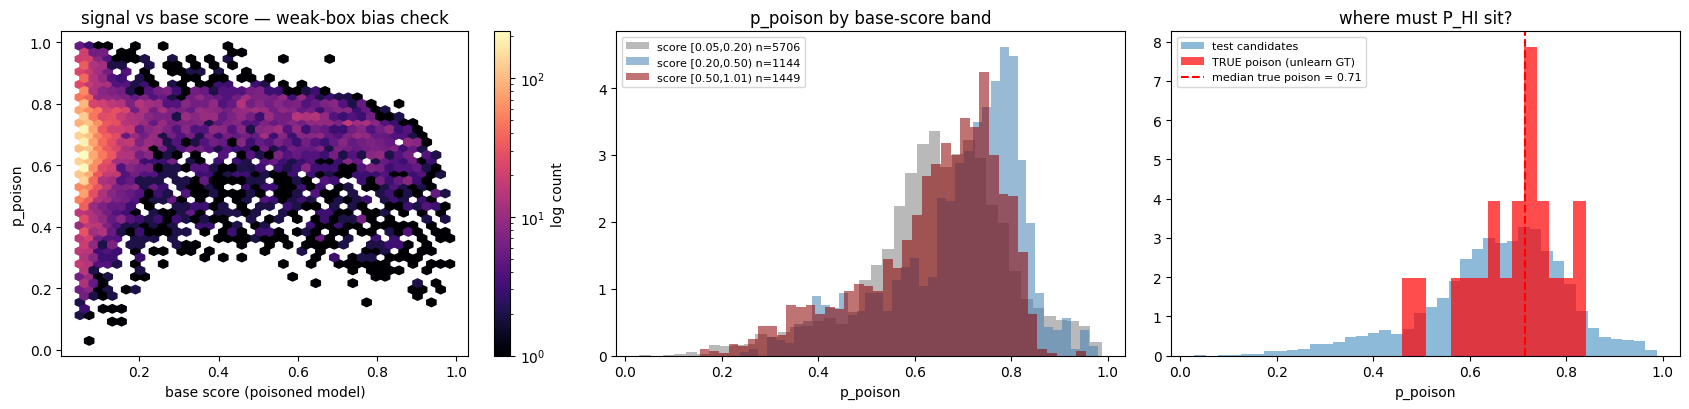

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2))
hb = ax[0].hexbin(all_s, all_p, gridsize=40, cmap="magma", mincnt=1, bins="log")
plt.colorbar(hb, ax=ax[0], label="log count")
ax[0].set(xlabel="base score (poisoned model)", ylabel="p_poison",
          title="signal vs base score — weak-box bias check")
for lo, hi, c in [(0.05, 0.2, "gray"), (0.2, 0.5, "steelblue"), (0.5, 1.01, "darkred")]:
    m = (all_s >= lo) & (all_s < hi)
    if m.any():
        ax[1].hist(all_p[m], bins=40, alpha=0.55, density=True, color=c,
                   label=f"score [{lo:.2f},{hi:.2f}) n={m.sum()}")
ax[1].set(xlabel="p_poison", title="p_poison by base-score band"); ax[1].legend(fontsize=8)
ax[2].hist(all_p, bins=40, alpha=0.5, density=True, label="test candidates")
if gt_p:
    ax[2].hist(gt_p, bins=15, alpha=0.7, density=True, color="red", label="TRUE poison (unlearn GT)")
    ax[2].axvline(np.median(gt_p), color="red", ls="--", label=f"median true poison = {np.median(gt_p):.2f}")
ax[2].set(xlabel="p_poison", title="where must P_HI sit?"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [30]:
import itertools
import numpy as np
import pandas as pd

def remap_confidence(s, p, R):
    """Returns 0.0 to DROP the box. eps-demotion reserved for plausible-match boxes only."""
    if s < R["MIN_KEEP"]:
        return 0.0                                     # noise-level candidate: drop (no eps spam)
    if p >= R["P_HI"]:
        return R["EPS"]                                # flagged poison, strong box: demote not delete
    if p <= R["P_LO"]:
        if R.get("BOOST") and s >= R["S_CONF"]:
            return R["C_MAX"]                          # boost only when explicitly enabled
        return float(s)                                # default: trust the poisoned model's conf
    frac = (p - R["P_LO"]) / max(R["P_HI"] - R["P_LO"], 1e-6)
    return float(max(R["EPS"], s * (1 - frac)))

def build_submission_preds(cand_preds, p_poison, R):
    out = {}
    for stem, (bx, sc) in cand_preds.items():
        if len(bx) == 0:
            out[stem] = (bx, sc); continue
        conf = np.array([remap_confidence(s, p, R) for s, p in zip(sc, p_poison[stem])], np.float32)
        keep = conf > 0
        eps_ids = np.where(conf <= R["EPS"] + 1e-6)[0]
        strong_ids = np.where(conf > 0.2)[0]
        if len(eps_ids) and len(strong_ids):
            overl = iou_matrix(bx[eps_ids], bx[strong_ids]).max(1)
            keep[eps_ids[overl >= 0.2]] = False  # <-- Fixed indentation here
        out[stem] = (bx[keep], conf[keep])
    return out

TUNED = None
if CALIBRATE:
    rng = np.random.default_rng(123)
    calib_imgs, calib_gt = [], []          # gt: list of (box, is_poison)
    stems = list(unlearn_imgs)
    for _ in range(60):
        stem = stems[rng.integers(len(stems))]
        img = unlearn_imgs[stem].copy()
        gts = [(bb, True) for bb in poison_boxes_by_stem.get(stem, [])]   # native poison
        for _ in range(rng.integers(1, 3)):                                # synthetic streaks
            g = img[:, :, 0]
            g2, box = synth_streak_on(g, rng)
            img = np.repeat(g2[:, :, None], 3, axis=2)
            gts.append((box, False))
        for _ in range(rng.integers(0, 3)):                                # transplanted poison
            patch = poison_patches[rng.integers(len(poison_patches))]
            ph, pw = patch.shape[:2]
            spot = rand_free_spot(stem, ph, pw, rng)
            if spot:
                x0, y0 = spot
                paste_patch(img, patch, x0, y0)
                gts.append(([x0 + MARGIN, y0 + MARGIN, x0 + pw - MARGIN, y0 + ph - MARGIN], True))
        calib_imgs.append(img); calib_gt.append(gts)

    calib_cand = predict_arrays(POISONED_WEIGHTS, calib_imgs, CFG["CAND_THRESH"], "calib_poisoned")
    calib_ens = {n: predict_arrays(w, calib_imgs, CFG["ENS_THRESH"], f"calib_{n}")
                 for n, w in ens_weights.items()}
    calib_diff = survival_scores_from_lists(calib_cand, calib_ens)
    calib_geo = [geometry_scores(bx) for bx, _ in calib_cand]
    calib_app = [appearance_scores_arr(im[:, :, 0], bx) for im, (bx, _) in zip(calib_imgs, calib_cand)]

    # clean reference: candidates matching a REAL streak GT keep their poisoned-model conf
    calib_clean = {}
    for i, ((bx, sc), gts) in enumerate(zip(calib_cand, calib_gt)):
        real = np.array([g for g, isp in gts if not isp], np.float32).reshape(-1, 4)
        if len(bx) and len(real):
            m = iou_matrix(bx, real).max(1) >= 0.3
            calib_clean[str(i)] = (bx[m], sc[m])
        else:
            calib_clean[str(i)] = (np.zeros((0, 4), np.float32), np.zeros(0, np.float32))

    grid = dict(W_DIFF=[0.6, 0.75, 0.9], P_HI=[0.40, 0.50, 0.60, 0.70],
                P_LO=[0.2, 0.3], MIN_KEEP=[0.08, 0.12, 0.20], BOOST=[False, True],
                S_CONF=[0.5], C_MAX=[0.95], EPS=[0.01])
    results = []
    for wd, ph_, pl, mk, bst, scf, cm, ep in itertools.product(*grid.values()):
        if ph_ <= pl:
            continue
        w = np.array([wd, 0.05, 1 - wd - 0.05]); w /= w.sum()
        pp = {str(i): w[0] * calib_diff[i] + w[1] * calib_geo[i] + w[2] * calib_app[i]
              for i in range(len(calib_cand))}
        R = dict(P_HI=ph_, P_LO=pl, MIN_KEEP=mk, BOOST=bst, S_CONF=scf, C_MAX=cm, EPS=ep)
        sub = build_submission_preds({str(i): calib_cand[i] for i in range(len(calib_cand))}, pp, R)
        results.append({"W_DIFF": wd, **R, "macadd": macadd(calib_clean, sub)})
    res_df = pd.DataFrame(results).sort_values("macadd")
    print(res_df.head(10).to_string(index=False))
    best = res_df.iloc[0]
    TUNED = dict(P_HI=best.P_HI, P_LO=best.P_LO, MIN_KEEP=best.MIN_KEEP,
                 BOOST=bool(best.BOOST), S_CONF=best.S_CONF, C_MAX=best.C_MAX, EPS=best.EPS)
    if TUNED["BOOST"]:
        print("⚠ calibration prefers BOOST=True — trust only after probe_boost095 confirms on LB")
    CFG["W_DIFF"], CFG["W_APP"] = float(best.W_DIFF), float(1 - best.W_DIFF - 0.05)
    CFG["W_GEO"] = 0.05
    p_poison_test = combine(s_diff_test, s_geo_test, s_app_test)
    p_poison_unlearn = combine(s_diff_unlearn, s_geo_unlearn, s_app_unlearn)
    print("\nTUNED remap:", TUNED, "| W_DIFF:", CFG["W_DIFF"])
else:
    print("calibration skipped (transplant gate) — using presets")


calib_ens_cls_lr7e-4_it15_s13: 100%|██████████| 60/60 [00:57<00:00,  1.05it/s]


 W_DIFF  P_HI  P_LO  MIN_KEEP  BOOST  S_CONF  C_MAX  EPS   macadd
    0.6   0.6   0.3      0.20  False     0.5   0.95 0.01 0.698065
    0.6   0.6   0.3      0.20   True     0.5   0.95 0.01 0.699173
    0.6   0.7   0.3      0.20  False     0.5   0.95 0.01 0.715407
    0.6   0.7   0.3      0.20   True     0.5   0.95 0.01 0.716515
    0.6   0.6   0.3      0.12  False     0.5   0.95 0.01 0.721203
    0.6   0.6   0.3      0.12   True     0.5   0.95 0.01 0.722311
    0.6   0.6   0.3      0.08  False     0.5   0.95 0.01 0.748313
    0.6   0.6   0.3      0.08   True     0.5   0.95 0.01 0.749421
    0.6   0.7   0.3      0.12  False     0.5   0.95 0.01 0.753233
    0.6   0.7   0.3      0.12   True     0.5   0.95 0.01 0.754341

TUNED remap: {'P_HI': np.float64(0.6), 'P_LO': np.float64(0.3), 'MIN_KEEP': np.float64(0.2), 'BOOST': False, 'S_CONF': np.float64(0.5), 'C_MAX': np.float64(0.95), 'EPS': np.float64(0.01)} | W_DIFF: 0.6


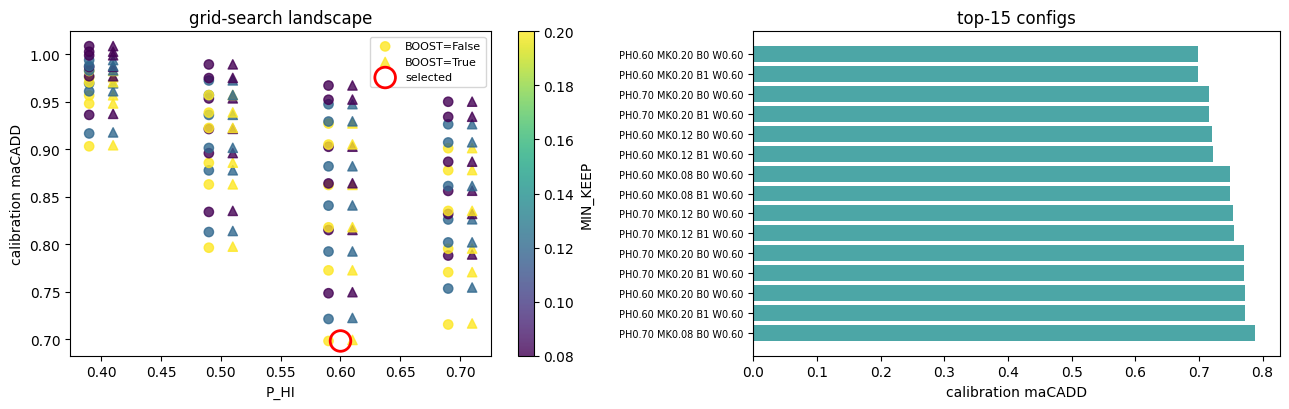

In [31]:
if TUNED is not None:
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    for bst, marker in [(False, "o"), (True, "^")]:
        d = res_df[res_df.BOOST == bst]
        s = ax[0].scatter(d.P_HI + (0.01 if bst else -0.01), d.macadd, c=d.MIN_KEEP,
                          cmap="viridis", marker=marker, s=45,
                          label=f"BOOST={bst}", alpha=0.8)
    plt.colorbar(s, ax=ax[0], label="MIN_KEEP")
    ax[0].scatter([TUNED["P_HI"]], [res_df.macadd.min()], s=220, facecolors="none",
                  edgecolors="red", lw=2, label="selected")
    ax[0].set(xlabel="P_HI", ylabel="calibration maCADD", title="grid-search landscape")
    ax[0].legend(fontsize=8)
    top = res_df.head(15).reset_index(drop=True)
    ax[1].barh(range(len(top)), top.macadd, color="teal", alpha=0.7)
    ax[1].set_yticks(range(len(top)))
    ax[1].set_yticklabels([f"PH{r.P_HI:.2f} MK{r.MIN_KEEP:.2f} B{int(r.BOOST)} W{r.W_DIFF:.2f}"
                           for r in top.itertuples()], fontsize=7)
    ax[1].invert_yaxis(); ax[1].set(xlabel="calibration maCADD", title="top-15 configs")
    plt.tight_layout(); plt.show()

In [32]:
variants = {"conservative": CFG["REMAP"]["CONSERVATIVE"],
            "aggressive": CFG["REMAP"]["AGGRESSIVE"]}
if TUNED is not None:
    variants["tuned"] = TUNED

subs_test = {n: build_submission_preds(poisoned_test, p_poison_test, R) for n, R in variants.items()}
subs_unlearn = {n: build_submission_preds(poisoned_unlearn, p_poison_unlearn, R)
                for n, R in variants.items()}

def poison_mass_on_unlearn(sub_unlearn):
    total = 0.0
    for stem, boxes in poison_boxes_by_stem.items():
        pb, ps = sub_unlearn.get(stem, (np.zeros((0, 4)), np.zeros(0)))
        if len(pb):
            m = iou_matrix(np.array(boxes, np.float32), pb)
            for i in range(len(boxes)):
                j = m[i].argmax()
                if m[i, j] >= 0.3:
                    total += ps[j]
    return total

print(f"poison mass — poisoned model: {poison_mass_on_unlearn(poisoned_unlearn):.2f} (floor ≈ 0.2)")
for n, s in subs_unlearn.items():
    print(f"poison mass — {n:>12}: {poison_mass_on_unlearn(s):.2f}")

FLAG = 0.6
surrogate = {stem: (bx[p_poison_test[stem] < FLAG], sc[p_poison_test[stem] < FLAG])
for stem, (bx, sc) in poisoned_test.items()}
print(f"\nsurrogate maCADD [raw poisoned]: {macadd(surrogate, poisoned_test):.4f}")
for n, s in subs_test.items():
    print(f"surrogate maCADD [{n:>12}]: {macadd(surrogate, s):.4f}")


poison mass — poisoned model: 11.72 (floor ≈ 0.2)
poison mass — conservative: 0.98
poison mass —   aggressive: 0.21
poison mass —        tuned: 0.39

surrogate maCADD [raw poisoned]: 0.7004
surrogate maCADD [conservative]: 0.1353
surrogate maCADD [  aggressive]: 0.1986
surrogate maCADD [       tuned]: 0.1514


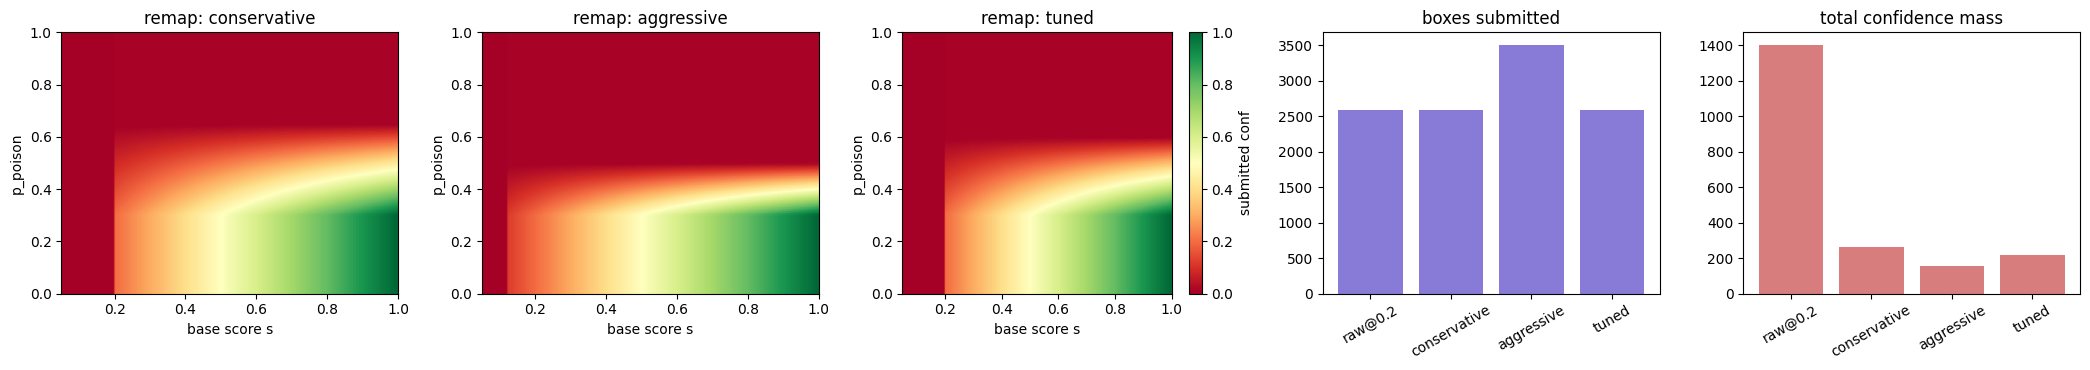

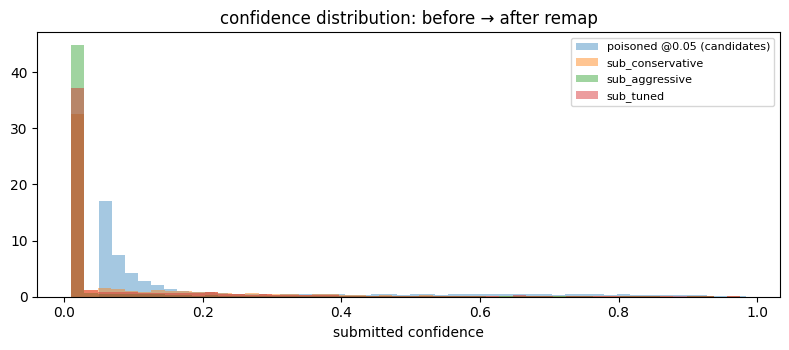

In [33]:
ss = np.linspace(0.05, 1.0, 120); pp_ = np.linspace(0, 1, 120)
fig, axes = plt.subplots(1, len(variants) + 2, figsize=(4.2 * (len(variants) + 2), 3.8))
for ax, (nme, R) in zip(axes, variants.items()):
    Z = np.array([[remap_confidence(s_, p_, R) for s_ in ss] for p_ in pp_])
    imh = ax.imshow(Z, origin="lower", extent=[ss[0], ss[-1], 0, 1], aspect="auto",
                    cmap="RdYlGn", vmin=0, vmax=1)
    ax.set(xlabel="base score s", ylabel="p_poison", title=f"remap: {nme}")
plt.colorbar(imh, ax=axes[len(variants) - 1], label="submitted conf")

axb = axes[-2]
names = ["raw@0.2"] + list(variants)
counts = [int(sum((sc >= 0.2).sum() for _, sc in poisoned_test.values()))] + \
         [sum(len(s_) for _, s_ in subs_test[n].values()) for n in variants]
masses = [float(sum(sc[sc >= 0.2].sum() for _, sc in poisoned_test.values()))] + \
         [float(sum(s_.sum() for _, s_ in subs_test[n].values())) for n in variants]
axb.bar(names, counts, color="slateblue", alpha=0.8)
axb.set_title("boxes submitted"); axb.tick_params(axis="x", rotation=30)
axm = axes[-1]
axm.bar(names, masses, color="indianred", alpha=0.8)
axm.set_title("total confidence mass"); axm.tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

# confidence distributions before/after
fig, ax = plt.subplots(1, 1, figsize=(8, 3.6))
base = np.concatenate([sc for _, sc in poisoned_test.values() if len(sc)])
ax.hist(base, bins=50, alpha=0.4, density=True, label="poisoned @0.05 (candidates)")
for nme in variants:
    v = np.concatenate([sc for _, sc in subs_test[nme].values() if len(sc)])
    ax.hist(v, bins=50, alpha=0.45, density=True, label=f"sub_{nme}")
ax.set(xlabel="submitted confidence", title="confidence distribution: before → after remap")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [34]:
sample = pd.read_csv(SAMPLE_SUB, dtype={"image_id": str})

def format_preds(bx, sc):
    parts = []
    for (x1, y1, x2, y2), s in zip(bx, sc):
        x1, y1 = float(np.clip(x1, 0, IMG_W)), float(np.clip(y1, 0, IMG_H))
        x2, y2 = float(np.clip(x2, 0, IMG_W)), float(np.clip(y2, 0, IMG_H))
        w, h = x2 - x1, y2 - y1
        if w > 0 and h > 0 and s > 0:
            parts += [f"{s:.6f}", f"{x1:.2f}", f"{y1:.2f}", f"{w:.2f}", f"{h:.2f}"]
    return " ".join(parts) or " "

def write_submission(sub_preds, path):
    df = sample.copy()
    df["prediction_string"] = df["image_id"].map(
        lambda i: format_preds(*sub_preds.get(str(i), (np.zeros((0, 4)), np.zeros(0)))))
    df.to_csv(path, index=False)
    n = sum(len(s) for _, s in sub_preds.values())
    print(f"saved {path} ({n} boxes)")
    return df

poisoned_t2 = {k: (bx[sc >= 0.2], sc[sc >= 0.2]) for k, (bx, sc) in poisoned_test.items()}
write_submission(poisoned_t2, WORK / "probe_raw_poisoned.csv")

# flag-only: poisoned @0.2 untouched EXCEPT flagged boxes -> eps. Cleanest discriminator A/B.
P_FLAG = TUNED["P_HI"] if TUNED is not None else 0.55
flag_only = {}
for k, (bx, sc) in poisoned_test.items():
    m = sc >= 0.2
    bxk, sck, ppk = bx[m], sc[m], p_poison_test[k][m]
    conf = np.where(ppk >= P_FLAG, 0.01, sck).astype(np.float32)
    flag_only[k] = (bxk, conf)
write_submission(flag_only, WORK / "sub_flag_only.csv")
write_submission({k: (bx, np.full(len(sc), 0.95, np.float32)) for k, (bx, sc) in poisoned_t2.items()},
                 WORK / "probe_boost095.csv")
for n, s in subs_test.items():
    write_submission(s, WORK / f"sub_{n}.csv")

saved working/probe_raw_poisoned.csv (2593 boxes)
saved working/sub_flag_only.csv (2593 boxes)
saved working/probe_boost095.csv (2593 boxes)
saved working/sub_conservative.csv (2586 boxes)
saved working/sub_aggressive.csv (3506 boxes)
saved working/sub_tuned.csv (2588 boxes)


In [37]:
import os
import shutil
from pathlib import Path

best_score = float('inf')
best_name = None

for name, sub in subs_test.items():
    score = macadd(surrogate, sub)
    print(f"{name:>12} : surrogate maCADD = {score:.4f}")
    if score < best_score:
        best_score = score
        best_name = name
print(f"\n🏆 Best variant based on surrogate maCADD: {best_name} (score = {best_score:.4f})")

# Use absolute path to avoid Python 3.9 relative path creation bug
work_dir = Path("/Volumes/hard/debris/working")
os.makedirs(work_dir, exist_ok=True)

src = work_dir / f"sub_{best_name}.csv"
dst = work_dir / "submission.csv"

shutil.copy(str(src), str(dst))
print(f"✅ '{src}' → '{dst}'")


conservative : surrogate maCADD = 0.1353
  aggressive : surrogate maCADD = 0.1986
       tuned : surrogate maCADD = 0.1514

🏆 Best variant based on surrogate maCADD: conservative (score = 0.1353)
✅ '/Volumes/hard/debris/working/sub_conservative.csv' → '/Volumes/hard/debris/working/submission.csv'
